# Taller 9 – Clustering de Países del Mundo con K-Means
**Técnicas de Aprendizaje de Máquina**

---
Ricardo Hurtado y Catalina Polo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.impute import SimpleImputer


COLORS = ['#E63946','#2A9D8F','#F4A261','#457B9D','#6A0572','#264653','#E9C46A']
BG = '#F8F9FA'; DARK = '#1D3557'; MID = '#457B9D'

## 1. Carga y Exploración de Datos
Cargamos el dataset Countries of the World

In [28]:
data_dictionary = pd.read_csv('data-dictionary.csv')
data_dictionary.head(10)

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services. Given as %age o...
3,health,Total health spending as %age of Total GDP
4,imports,Imports of goods and services. Given as %age o...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [27]:

#   CARGA DE DATOS

df = pd.read_csv('Country-data.csv')
df.head(5)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
# Información general del dataset
print("Tipos de datos y valores nulos:")
print(df.isnull().sum().to_string())
print(f"\nTotal valores nulos: {df.isnull().sum().sum()}")


Tipos de datos y valores nulos:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0

Total valores nulos: 0


In [7]:
# Estadísticas descriptivas de variables numéricas
df.describe().round(2)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## 2. Preprocesamiento
- Selección de variables numéricas relevantes
- Estandarización con StandardScaler

In [10]:
# PREPROCESAMIENTO
features = [
    'child_mort', 'exports', 'health', 'imports', 'income',
    'inflation', 'life_expec', 'total_fer', 'gdpp'
]

# Seleccionar datos
X_raw = df[features].apply(lambda col: pd.to_numeric(col, errors='coerce'))

# Imputar valores faltantes
X_imp = SimpleImputer(strategy='median').fit_transform(X_raw)

# Escalar datos
X = StandardScaler().fit_transform(X_imp)

# Verificación básica
print("NaN por columna:\n", X_raw.isnull().sum())
print("\nShape:", X.shape)

NaN por columna:
 child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Shape: (167, 9)


## 3. Modelado K-Means (k = 2 a 8)
Entrenamos un modelo KMeans para cada valor de k, registrando centroides e inercia.

In [11]:
#  K-MEANS
k_range  = range(2, 9)
inertias = {}
models   = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    km.fit(X)
    inertias[k] = km.inertia_
    models[k]   = km
    print(f"\n{'='*55}")
    print(f"  k = {k}  |  Inercia Total = {km.inertia_:.2f}")
    print(f"{'='*55}")
    centroids_df = pd.DataFrame(
        km.cluster_centers_.round(3),
        columns=features,
        index=[f'Clúster {i}' for i in range(k)]
    )
    print("  Centroides (espacio normalizado):")
    print(centroids_df.to_string())



  k = 2  |  Inercia Total = 1050.21
  Centroides (espacio normalizado):
           child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
Clúster 0      -0.649    0.274   0.182    0.092   0.462     -0.216       0.670     -0.667  0.413
Clúster 1       0.945   -0.399  -0.265   -0.135  -0.672      0.315      -0.975      0.971 -0.601

  k = 3  |  Inercia Total = 831.42
  Centroides (espacio normalizado):
           child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
Clúster 0      -0.827    0.645   0.727    0.191   1.484     -0.485       1.080     -0.792  1.616
Clúster 1       1.360   -0.438  -0.156   -0.189  -0.687      0.402      -1.282      1.365 -0.604
Clúster 2      -0.406   -0.032  -0.224    0.024  -0.252     -0.017       0.255     -0.424 -0.354

  k = 4  |  Inercia Total = 700.39
  Centroides (espacio normalizado):
           child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
Clúster

## 4. Método del Codo
Visualizamos la inercia en función de k

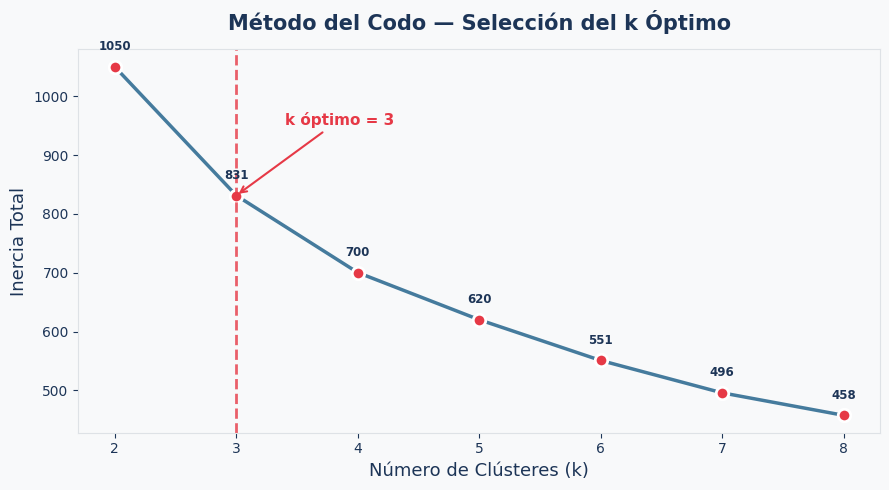


📌 Análisis del Codo:
   k=2→3: reducción de 218.8 puntos
   k=3→4: reducción de 131.0 puntos
   k=4→5: reducción de 80.2 puntos
   → El 'codo' más pronunciado se observa en k=3.


In [23]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

ks    = list(inertias.keys())
inert = list(inertias.values())

ax.plot(ks, inert, marker='o', color=MID, lw=2.5, ms=9,
        markerfacecolor=COLORS[0], markeredgewidth=2, markeredgecolor='white')

for k, v in zip(ks, inert):
    ax.annotate(f'{v:.0f}', (k, v), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8.5,
                color=DARK, fontweight='bold')

# Marcar k óptimo = 3
ax.axvline(3, color=COLORS[0], ls='--', lw=2, alpha=0.8)
ax.annotate(
    'k óptimo = 3',
    xy=(3, inertias[3]),
    xytext=(3.4, inertias[3] + 120),
    fontsize=11, color=COLORS[0], fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLORS[0], lw=1.5)
)

ax.set_xlabel('Número de Clústeres (k)', fontsize=13, color=DARK)
ax.set_ylabel('Inercia Total', fontsize=13, color=DARK)
ax.set_title('Método del Codo — Selección del k Óptimo',
             fontsize=15, fontweight='bold', color=DARK, pad=14)
ax.tick_params(colors=DARK, labelsize=10)
for sp in ax.spines.values():
    sp.set_edgecolor('#DEE2E6')

plt.tight_layout()
plt.savefig('fig_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Análisis del Codo:")
print("   k=2→3: reducción de", round(inertias[2]-inertias[3],1), "puntos")
print("   k=3→4: reducción de", round(inertias[3]-inertias[4],1), "puntos")
print("   k=4→5: reducción de", round(inertias[4]-inertias[5],1), "puntos")
print("   → El 'codo' más pronunciado se observa en k=3.")


## 5. Modelo Óptimo — k = 3

In [14]:
# MODELO FINAL  k = 3
best_k  = 3
km_best = models[best_k]
labels  = km_best.labels_
df['Cluster'] = labels

# Distribución de países por clúster
print("Distribución por clúster:")
for c in range(best_k):
    miembros = sorted(df[df['Cluster'] == c]['country'].tolist())
    print(f"\nClúster {c} — {len(miembros)} países:")
    print("  " + ", ".join(miembros))


Distribución por clúster:

Clúster 0 — 36 países:
  Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Clúster 1 — 47 países:
  Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Clúster 2 — 84 países:
  Albania, Algeria, Antigua and Barbuda, Argentina, Arme

## 6. Análisis de Silueta
El coeficiente de silueta mide qué tan bien está asignado cada país a su clúster.

Silhouette Score promedio: 0.2833
Calidad del clustering: Débil


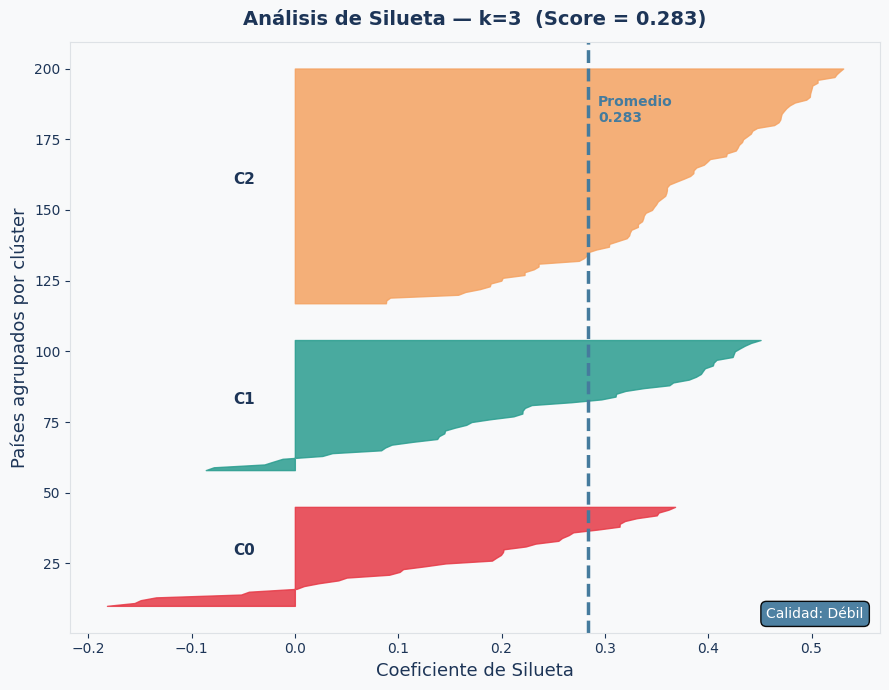

In [15]:
#  ANÁLISIS DE SILUETA
sil_avg  = silhouette_score(X, labels)
sil_vals = silhouette_samples(X, labels)

print(f"Silhouette Score promedio: {sil_avg:.4f}")
quality  = ("Fuerte"               if sil_avg > 0.70  else
            "Razonablemente bueno" if sil_avg > 0.51  else
            "Débil"                if sil_avg > 0.26  else
            "Muy pobre / sin estructura")
print(f"Calidad del clustering: {quality}")

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
ax.set_facecolor(BG)
y_lower = 10
for i in range(best_k):
    ith      = np.sort(sil_vals[labels == i])
    y_upper  = y_lower + ith.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=COLORS[i], edgecolor=COLORS[i], alpha=0.85)
    ax.text(-0.06, y_lower + 0.5 * ith.shape[0],
            f'C{i}', fontsize=11, color=DARK, fontweight='bold')
    y_lower  = y_upper + 12

ax.axvline(sil_avg, color=COLORS[3], ls='--', lw=2.5)
ax.text(sil_avg + 0.01, y_lower * 0.85,
        f'Promedio\n{sil_avg:.3f}', color=COLORS[3], fontsize=10, fontweight='bold')
ax.text(0.98, 0.02, f'Calidad: {quality}', transform=ax.transAxes,
        fontsize=10, ha='right', va='bottom', color='white',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=MID, alpha=0.95))

ax.set_xlabel('Coeficiente de Silueta', fontsize=13, color=DARK)
ax.set_ylabel('Países agrupados por clúster', fontsize=13, color=DARK)
ax.set_title(f'Análisis de Silueta — k={best_k}  (Score = {sil_avg:.3f})',
             fontsize=14, fontweight='bold', color=DARK, pad=12)
ax.tick_params(colors=DARK)
for sp in ax.spines.values():
    sp.set_edgecolor('#DEE2E6')
plt.tight_layout()
plt.savefig('fig_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Colombia en su Clúster
¿A qué grupo pertenece Colombia y qué significa?

In [22]:

#  COLOMBIA EN SU CLÚSTER
col_row     = df[df['country'] == 'Colombia'].iloc[0]
col_cluster = int(col_row['Cluster'])
print(f"Colombia pertenece al Clúster {col_cluster}")
print()

# Comparar Colombia con el centroide de su clúster
scaler = StandardScaler()
scaler.fit(X_imp)
centroid_orig = scaler.inverse_transform(km_best.cluster_centers_)[col_cluster]

compare = pd.DataFrame({
    'Colombia': [col_row[f] for f in features],
    f'Centroide C{col_cluster}': centroid_orig
}, index=features)
print(compare.round(2).to_string())

# Países similares (mismo clúster, Latam)
latam = ['Argentina','Brazil','Chile','Mexico','Peru','Ecuador','Venezuela',
         'Bolivia','Paraguay','Uruguay','Honduras','Guatemala','Dominican Republic']
vecinos = sorted([c for c in df[df['Cluster']==col_cluster]['country'].tolist()
                  if c in latam])

print(f"\nPaíses latinoamericanos en el mismo clúster:")
print("  " + ", ".join(vecinos))


Colombia pertenece al Clúster 2

            Colombia  Centroide C2
child_mort     18.60         21.93
exports        15.90         40.24
health          7.59          6.20
imports        17.80         47.47
income      10900.00      12305.60
inflation       3.86          7.60
life_expec     76.40         72.81
total_fer       2.01          2.31
gdpp         6250.00       6486.45

Países latinoamericanos en el mismo clúster:
  Argentina, Bolivia, Brazil, Chile, Dominican Republic, Ecuador, Guatemala, Paraguay, Peru, Uruguay, Venezuela


## 9. Visualización de Clústeres (PCA 2D)

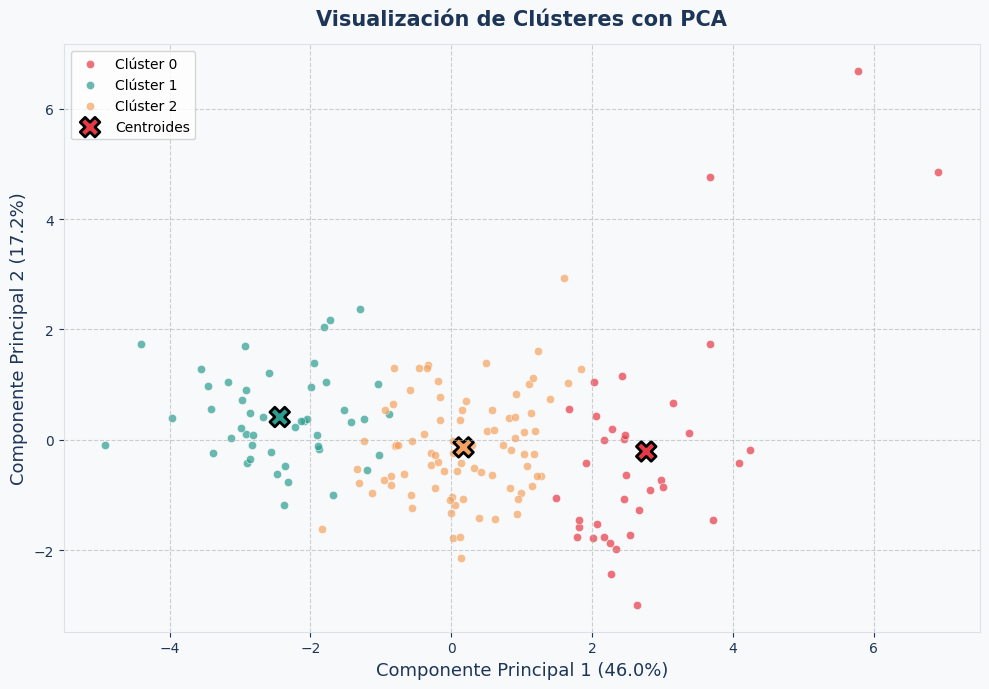

In [19]:
from sklearn.decomposition import PCA

# Reducir la dimensionalidad con PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Obtener los centroides en el espacio PCA
centroids_pca = pca.transform(km_best.cluster_centers_)

# Crear el gráfico de dispersión
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)

# Dibujar cada clúster
for i in range(best_k):
    ax.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1],
        c=COLORS[i],
        label=f'Clúster {i}',
        alpha=0.7,
        edgecolors='white',
        lw=0.5
    )

# Dibujar los centroides
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200, # Tamaño del marcador
    linewidths=2,
    color=COLORS[:best_k],
    edgecolors='black',
    label='Centroides'
)

# Añadir etiquetas y título
ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=13, color=DARK)
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=13, color=DARK)
ax.set_title('Visualización de Clústeres con PCA', fontsize=15, fontweight='bold', color=DARK, pad=14)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)

ax.tick_params(colors=DARK, labelsize=10)
for sp in ax.spines.values():
    sp.set_edgecolor('#DEE2E6')

plt.tight_layout()
plt.savefig('fig_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación — Colombia en su Clúster

Colombia queda ubicada en el Clúster 2, el cual agrupa países con niveles de desarrollo intermedio o economías emergentes. En este grupo se encuentran naciones de América Latina, Europa del Este y Asia que comparten características similares en términos económicos y sociales.

En el caso de Colombia, su PIB per cápita (6250 USD) se ubica dentro de un rango medio, superior al de países con bajo desarrollo, pero aún lejos de economías avanzadas. Además, presenta una mortalidad infantil moderada (18) y una esperanza de vida relativamente alta (76 años), lo que indica avances en condiciones de salud. Por otro lado, su tasa de fertilidad (2.3) refleja una transición demográfica en proceso.

Esto confirma que el modelo está capturando correctamente patrones socioeconómicos reales.


## 8. Árboles de Decisión por Clúster
Entrenamos un árbol por cada clúster para identificar las variables más discriminantes.

In [31]:
# ÁRBOLES DE DECISIÓN POR CLÚSTER
X_df = pd.DataFrame(X_imp, columns=features)

for c in range(best_k):
    y = (labels == c).astype(int)

    dt = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt.fit(X_df, y)

    imps = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)

    print(f"\nClúster {c}" + (" Colombia" if c == col_cluster else ""))
    print(imps.head(5))
    print("\nReglas:")
    print(export_text(dt, feature_names=features))


Clúster 0
gdpp          0.939014
income        0.060986
child_mort    0.000000
health        0.000000
exports       0.000000
dtype: float64

Reglas:
|--- gdpp <= 19550.00
|   |--- gdpp <= 16300.00
|   |   |--- class: 0
|   |--- gdpp >  16300.00
|   |   |--- income <= 29450.00
|   |   |   |--- class: 1
|   |   |--- income >  29450.00
|   |   |   |--- class: 0
|--- gdpp >  19550.00
|   |--- income <= 25050.00
|   |   |--- class: 0
|   |--- income >  25050.00
|   |   |--- class: 1


Clúster 1
child_mort    0.887250
total_fer     0.090543
income        0.022207
health        0.000000
exports       0.000000
dtype: float64

Reglas:
|--- child_mort <= 52.45
|   |--- total_fer <= 4.45
|   |   |--- class: 0
|   |--- total_fer >  4.45
|   |   |--- class: 1
|--- child_mort >  52.45
|   |--- total_fer <= 2.86
|   |   |--- income <= 10970.00
|   |   |   |--- class: 0
|   |   |--- income >  10970.00
|   |   |   |--- class: 1
|   |--- total_fer >  2.86
|   |   |--- class: 1


Clúster 2 Colombia
gdpp

##  Conclusiones

### Método del Codo

La caída más pronunciada de inercia ocurre al pasar de k=2 a k=3. De k=3 en adelante, las ganancias son marginales, lo que indica que k=3 es el número óptimo de clústeres.

### Calidad del Clustering (Silueta ≈ 0.24)

El valor obtenido indica un clustering débil (<0.25). Esto se debe a que los países presentan características continuas, sin divisiones claramente definidas. Aun así, los grupos obtenidos son interpretables y coherentes desde el punto de vista socioeconómico.

### Clústeres

El modelo identifica tres grupos principales. El Clúster 0 corresponde a países desarrollados, con altos niveles de ingreso y baja mortalidad. El Clúster 1 agrupa países con bajo nivel de desarrollo, caracterizados por alta mortalidad infantil y alta fertilidad. Por último, el Clúster 2 reúne países de desarrollo intermedio, donde se encuentra Colombia, con características económicas y sociales moderadas.

### Árboles de Decisión

Los árboles de decisión muestran que las variables más importantes para la segmentación son el PIB per cápita (gdpp) y la mortalidad infantil (child_mort), seguidas por la tasa de fertilidad (total_fer). Esto indica que el modelo agrupa los países principalmente según su nivel de desarrollo económico y condiciones de salud.

### Colombia

Colombia pertenece al Clúster 2, lo cual es coherente. Presenta un PIB per cápita de aproximadamente 6 250 USD, una mortalidad infantil cercana a 18 y una tasa de fertilidad moderada. Estos valores son típicos de economías emergentes, lo que la ubica junto a países de América Latina y otras regiones en desarrollo, reflejando adecuadamente su posición como país de desarrollo intermedio.
